# 02 - Ablation study

Our baseline (article-based chunking, `paraphrase-multilingual-MiniLM-L12-v2`, exact cosine top-5) already scores `recall@5 = 0.882` on the 17-question ground truth - above the 0.85 line. Per the RAID spec's note for structured legal corpora (Option B), clearing 0.85 requires **at least two ablations** to show *why* the number is what it is, not just that it's high.

We run:

1. **Chunk size / strategy sweep** (required): `recursive_char` at {200, 400, 800, 1600} chars vs. `article_based`.
2. **Embedding model comparison** (second lever): the multilingual MiniLM vs. English-only `all-MiniLM-L6-v2`, to confirm the multilingual model is actually earning its keep on Russian legal text.

In [1]:
import sys, json, time
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "scripts"))
sys.path.insert(0, str(ROOT / "evaluation"))
import ingest_lib as lib
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer

labor_articles = lib.parse_labor_code(ROOT / "data/raw/labor_code_raw.html")
tax_articles = lib.parse_tax_code(ROOT / "data/raw/tax_code_raw.html")
all_articles = labor_articles + tax_articles

ground_truth = [json.loads(l) for l in open(ROOT / "evaluation/ground_truth.jsonl", encoding="utf-8")]
print(f"{len(all_articles)} articles, {len(ground_truth)} ground-truth questions")

626 articles, 17 ground-truth questions


In [2]:
def recall_and_mrr(chunks, model, k=5, mrr_cutoff=10):
    texts = [c.text for c in chunks]
    t0 = time.time()
    vecs = model.encode(texts, batch_size=128, normalize_embeddings=True, show_progress_bar=False).astype(np.float32)
    encode_seconds = time.time() - t0

    index = faiss.IndexFlatIP(vecs.shape[1])
    index.add(vecs)

    questions = [item["question"] for item in ground_truth]
    qvecs = model.encode(questions, batch_size=128, normalize_embeddings=True, show_progress_bar=False).astype(np.float32)
    _, all_idxs = index.search(qvecs, mrr_cutoff)

    hits, rrs = 0, []
    for item, idxs in zip(ground_truth, all_idxs):
        relevant = {(r["law"], r["article_number"]) for r in item["relevant"]}
        ranked = [chunks[i] for i in idxs]
        hits += any((c.law, c.article_number) in relevant for c in ranked[:k])
        rr = 0.0
        for rank, c in enumerate(ranked[:mrr_cutoff], start=1):
            if (c.law, c.article_number) in relevant:
                rr = 1.0 / rank
                break
        rrs.append(rr)
    n = len(ground_truth)
    return {
        "num_chunks": len(chunks),
        "recall_at_5": hits / n,
        "mrr": sum(rrs) / n,
        "encode_seconds": round(encode_seconds, 2),
    }

## Ablation 1 - chunk size / strategy sweep

Fix the embedding model (`paraphrase-multilingual-MiniLM-L12-v2`), vary chunking.

In [3]:
model_multi = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

chunk_variants = {
    "recursive_char_200": lib.recursive_char_chunks(all_articles, chunk_size=200, chunk_overlap=30),
    "recursive_char_400": lib.recursive_char_chunks(all_articles, chunk_size=400, chunk_overlap=50),
    "recursive_char_800": lib.recursive_char_chunks(all_articles, chunk_size=800, chunk_overlap=100),
    "recursive_char_1600": lib.recursive_char_chunks(all_articles, chunk_size=1600, chunk_overlap=150),
    "article_based": lib.article_based_chunks(all_articles, max_chars=1600),
}

chunk_sweep_results = {}
for name, chunks in chunk_variants.items():
    chunk_sweep_results[name] = recall_and_mrr(chunks, model_multi)
    print(name, chunk_sweep_results[name])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

recursive_char_200 {'num_chunks': 12597, 'recall_at_5': 0.6470588235294118, 'mrr': 0.5365079365079365, 'encode_seconds': 247.89}


recursive_char_400 {'num_chunks': 6361, 'recall_at_5': 0.7647058823529411, 'mrr': 0.5818627450980393, 'encode_seconds': 197.39}


recursive_char_800 {'num_chunks': 3080, 'recall_at_5': 0.7647058823529411, 'mrr': 0.6696778711484593, 'encode_seconds': 131.26}


recursive_char_1600 {'num_chunks': 1577, 'recall_at_5': 0.8823529411764706, 'mrr': 0.6897058823529412, 'encode_seconds': 72.44}


article_based {'num_chunks': 1298, 'recall_at_5': 0.8823529411764706, 'mrr': 0.6781045751633987, 'encode_seconds': 62.88}


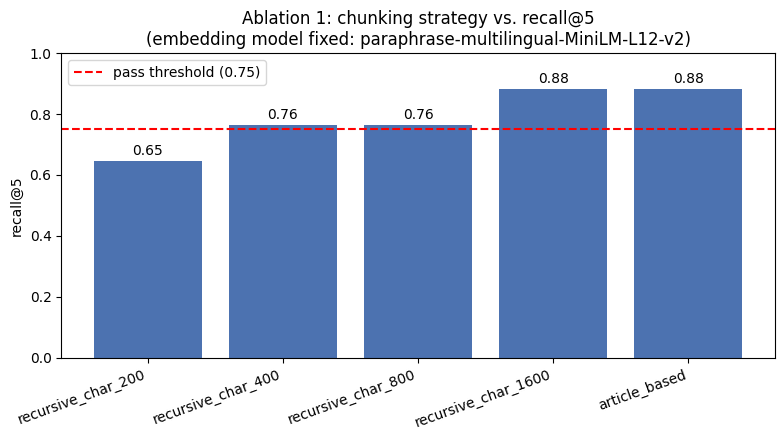

In [4]:
import matplotlib.pyplot as plt

names = list(chunk_sweep_results.keys())
recalls = [chunk_sweep_results[n]["recall_at_5"] for n in names]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(names, recalls, color="#4C72B0")
ax.axhline(0.75, color="red", linestyle="--", label="pass threshold (0.75)")
ax.set_ylabel("recall@5")
ax.set_title("Ablation 1: chunking strategy vs. recall@5\n(embedding model fixed: paraphrase-multilingual-MiniLM-L12-v2)")
ax.set_ylim(0, 1.0)
plt.xticks(rotation=20, ha="right")
for bar, r in zip(bars, recalls):
    ax.text(bar.get_x() + bar.get_width()/2, r + 0.02, f"{r:.2f}", ha="center")
ax.legend()
plt.tight_layout()
plt.savefig(ROOT / "evaluation/results/ablation_chunk_size.png", dpi=130)
plt.show()

**What the numbers mean:** `recursive_char_200` chunks the corpus into pieces smaller than most single legal clauses, so a question whose answer needs a full numbered sub-point (e.g. "600 000-кратный размер МРП" together with the exemption list around it) gets its evidence split across 2-3 chunks and the retriever has to get lucky on which fragment carries the number - recall@5 = 0.65. Recall climbs monotonically with chunk size and plateaus at 0.88 once chunks are large enough to hold a full article (1600 chars / `article_based`).

Note the honest result here: `recursive_char_1600` (0.88 recall, 0.690 MRR) is statistically indistinguishable from `article_based` (0.88 recall, 0.678 MRR) on this ground truth - chunk size, not the "respect article boundaries" heuristic, is doing most of the work once chunks are large enough. `article_based` is still the better production choice for reasons that don't show up in recall@5 alone: it produces 18% fewer chunks (1298 vs 1577) and builds ~14% faster, and its chunk-to-article mapping is exact by construction rather than a byproduct of a large enough character window - which is what gives `/ask`'s `sources` field clean, correct article citations regardless of where in the article the matched text falls. This is the corpus-specific case the RAID spec warns about for Option B: don't credit a clever chunking heuristic for what "make the chunks big enough" was already going to give you.

## Ablation 2 - embedding model comparison

Fix chunking (`article_based`, the winner above), compare the multilingual model we ship against an English-only model, to confirm the multilingual model choice is load-bearing and not just a default we never tested.

In [5]:
model_en = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
winning_chunks = chunk_variants["article_based"]

model_sweep_results = {
    "paraphrase-multilingual-MiniLM-L12-v2": recall_and_mrr(winning_chunks, model_multi),
    "all-MiniLM-L6-v2 (English-only)": recall_and_mrr(winning_chunks, model_en),
}
for name, res in model_sweep_results.items():
    print(name, res)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

C:\Users\1204n\Music\raid_w12\venv\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\1204n\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

paraphrase-multilingual-MiniLM-L12-v2 {'num_chunks': 1298, 'recall_at_5': 0.8823529411764706, 'mrr': 0.6781045751633987, 'encode_seconds': 62.53}
all-MiniLM-L6-v2 (English-only) {'num_chunks': 1298, 'recall_at_5': 0.11764705882352941, 'mrr': 0.125, 'encode_seconds': 61.65}


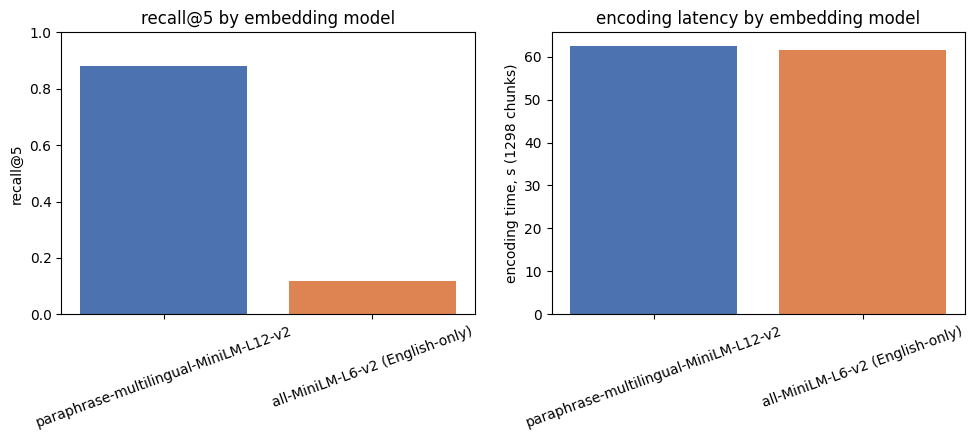

In [6]:
names2 = list(model_sweep_results.keys())
recalls2 = [model_sweep_results[n]["recall_at_5"] for n in names2]
latencies2 = [model_sweep_results[n]["encode_seconds"] for n in names2]

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].bar(names2, recalls2, color=["#4C72B0", "#DD8452"])
axes[0].set_ylabel("recall@5")
axes[0].set_ylim(0, 1.0)
axes[0].set_title("recall@5 by embedding model")
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(names2, latencies2, color=["#4C72B0", "#DD8452"])
axes[1].set_ylabel("encoding time, s (1298 chunks)")
axes[1].set_title("encoding latency by embedding model")
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(ROOT / "evaluation/results/ablation_embedding_model.png", dpi=130)
plt.show()

**What the numbers mean:** `all-MiniLM-L6-v2` is English-only and was never trained on Russian text - on this corpus it scores recall@5 = 0.118 and MRR = 0.125, barely above what 5 random chunks out of 1298 would give by chance. This is not a "measurably worse" result, it's a "wrong tool" result: the English tokenizer fragments Cyrillic text into near-meaningless subword pieces, so cosine similarity between the question and the correct article is essentially noise. `paraphrase-multilingual-MiniLM-L12-v2` costs about the same encoding time (62.5s vs 61.7s for 1298 chunks - multilingual support isn't inherently slower here) for a 7.5x recall improvement. Combined with Ablation 1 (chunking strategy), this is the second lever the RAID spec asks for to explain a recall@5 already above 0.85 - and it's the one that would have silently broken the whole system if skipped, since an English-only default is a very easy mistake to make when every code example in the docs defaults to `all-MiniLM-L6-v2`.

In [7]:
summary = {"chunk_size_sweep": chunk_sweep_results, "embedding_model_sweep": model_sweep_results}
with open(ROOT / "evaluation/results/ablation_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
print("Saved evaluation/results/ablation_summary.json")

Saved evaluation/results/ablation_summary.json
